In [28]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv('King county housing.csv')

In [3]:
# Show every single column
pd.set_option('display.max_columns', None)

In [4]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,3,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,3,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,3,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,3,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [5]:
# View the first 5 rows, but flipped so columns are vertical
df.head(1).T

,0
id,7129300520
date,20141013T000000
price,221900.0
bedrooms,3
bathrooms,1.0
sqft_living,1180
sqft_lot,5650
floors,1.0
waterfront,0
view,0


## Data discovery and relations

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [8]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
df.describe(include='O')

,date
count,21613
unique,372
top,20140623T000000
freq,142


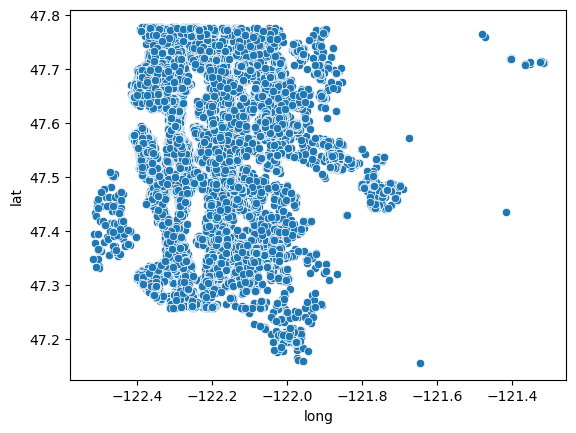

In [10]:
sns.scatterplot(x = df['long'] , y = df['lat']);

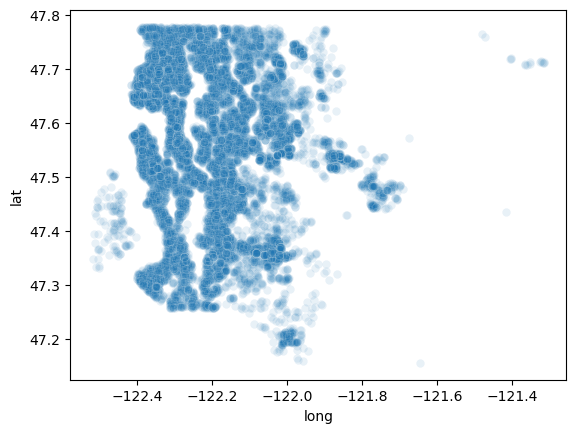

In [11]:
sns.scatterplot(x = df['long'] , y = df['lat'] , alpha = .1 );

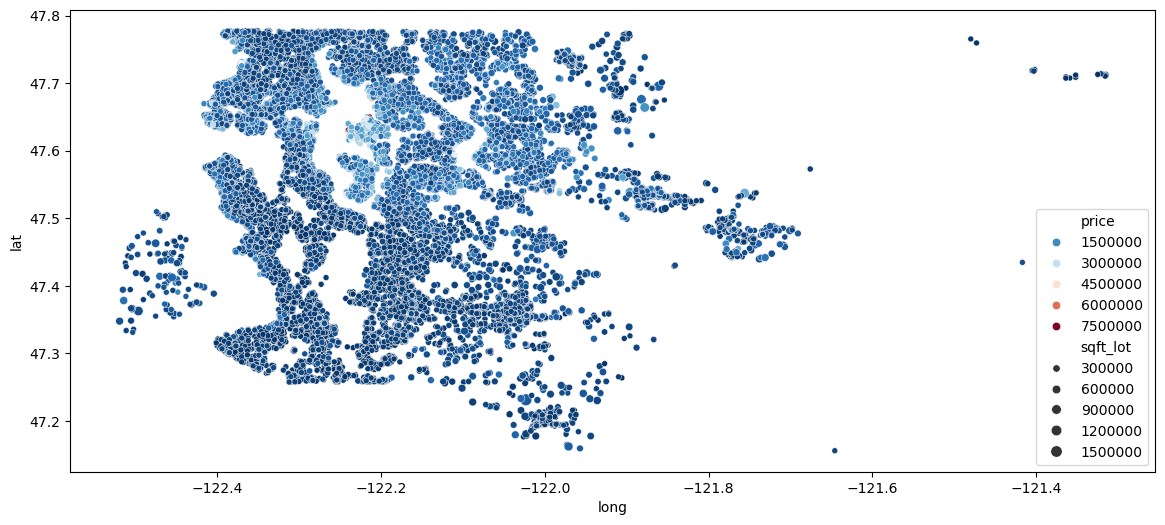

In [12]:
plt.figure(figsize=(14,6))
sns.scatterplot(x = df['long'] , y = df['lat'] , hue = df['price'] , palette='RdBu_r', size=df['sqft_lot']);

In [13]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
id              -0.016762
zipcode         -0.053203
Name: price, dtype: float64

### droping some features that can cause overfitting 

**id , grade, zipcode**: overfitting.  

In [22]:
df_modified = df.drop(columns=['grade', 'id','zipcode' ])

In [880]:
df_modified.shape

(21613, 18)

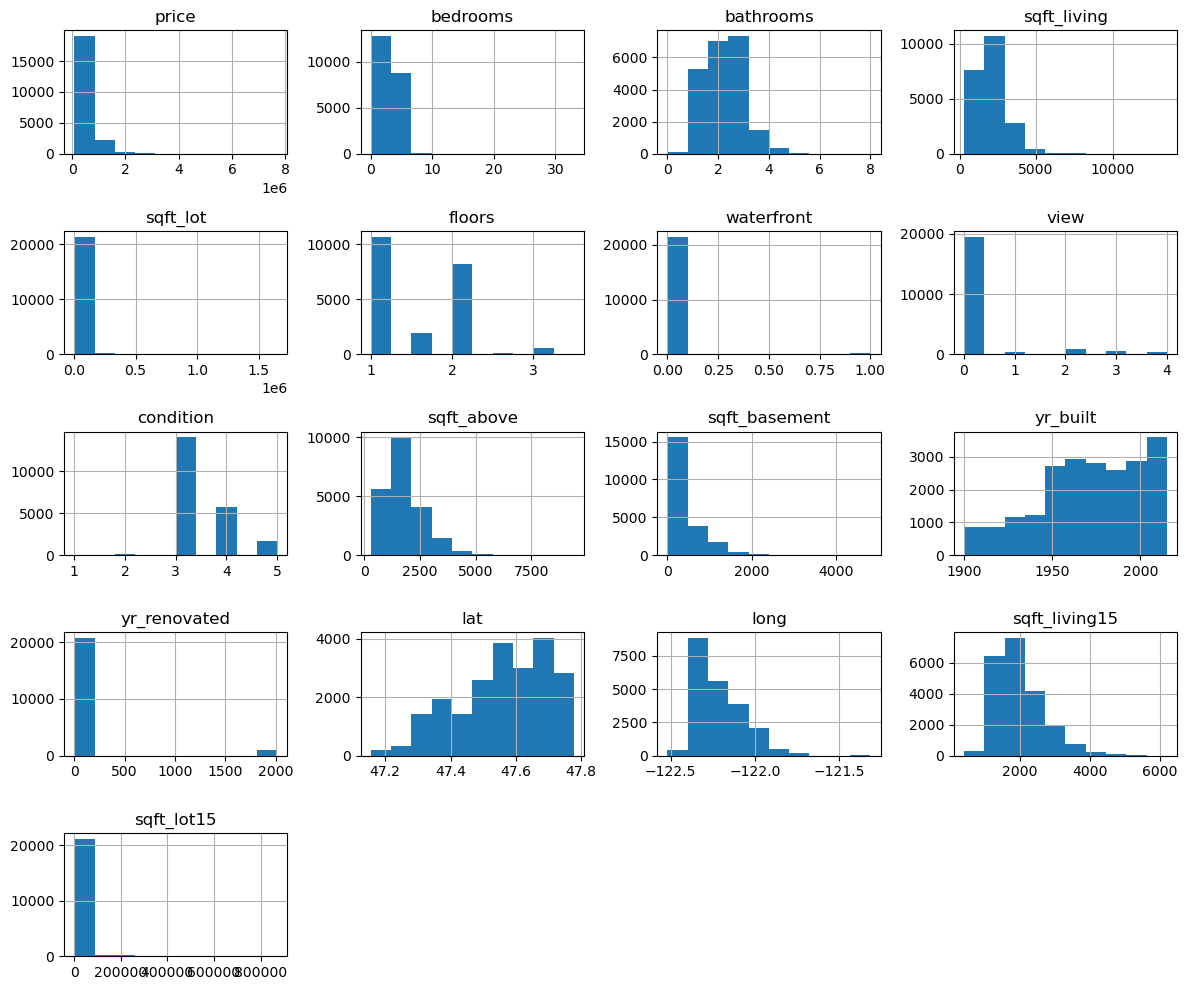

In [882]:
df_modified.hist(figsize=(12,10))
plt.tight_layout();

In [883]:
corr_matrix = df_modified.corr(numeric_only=True)
corr_matrix['price'].sort_values(ascending=False)

price            1.000000
sqft_living      0.702035
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
Name: price, dtype: float64

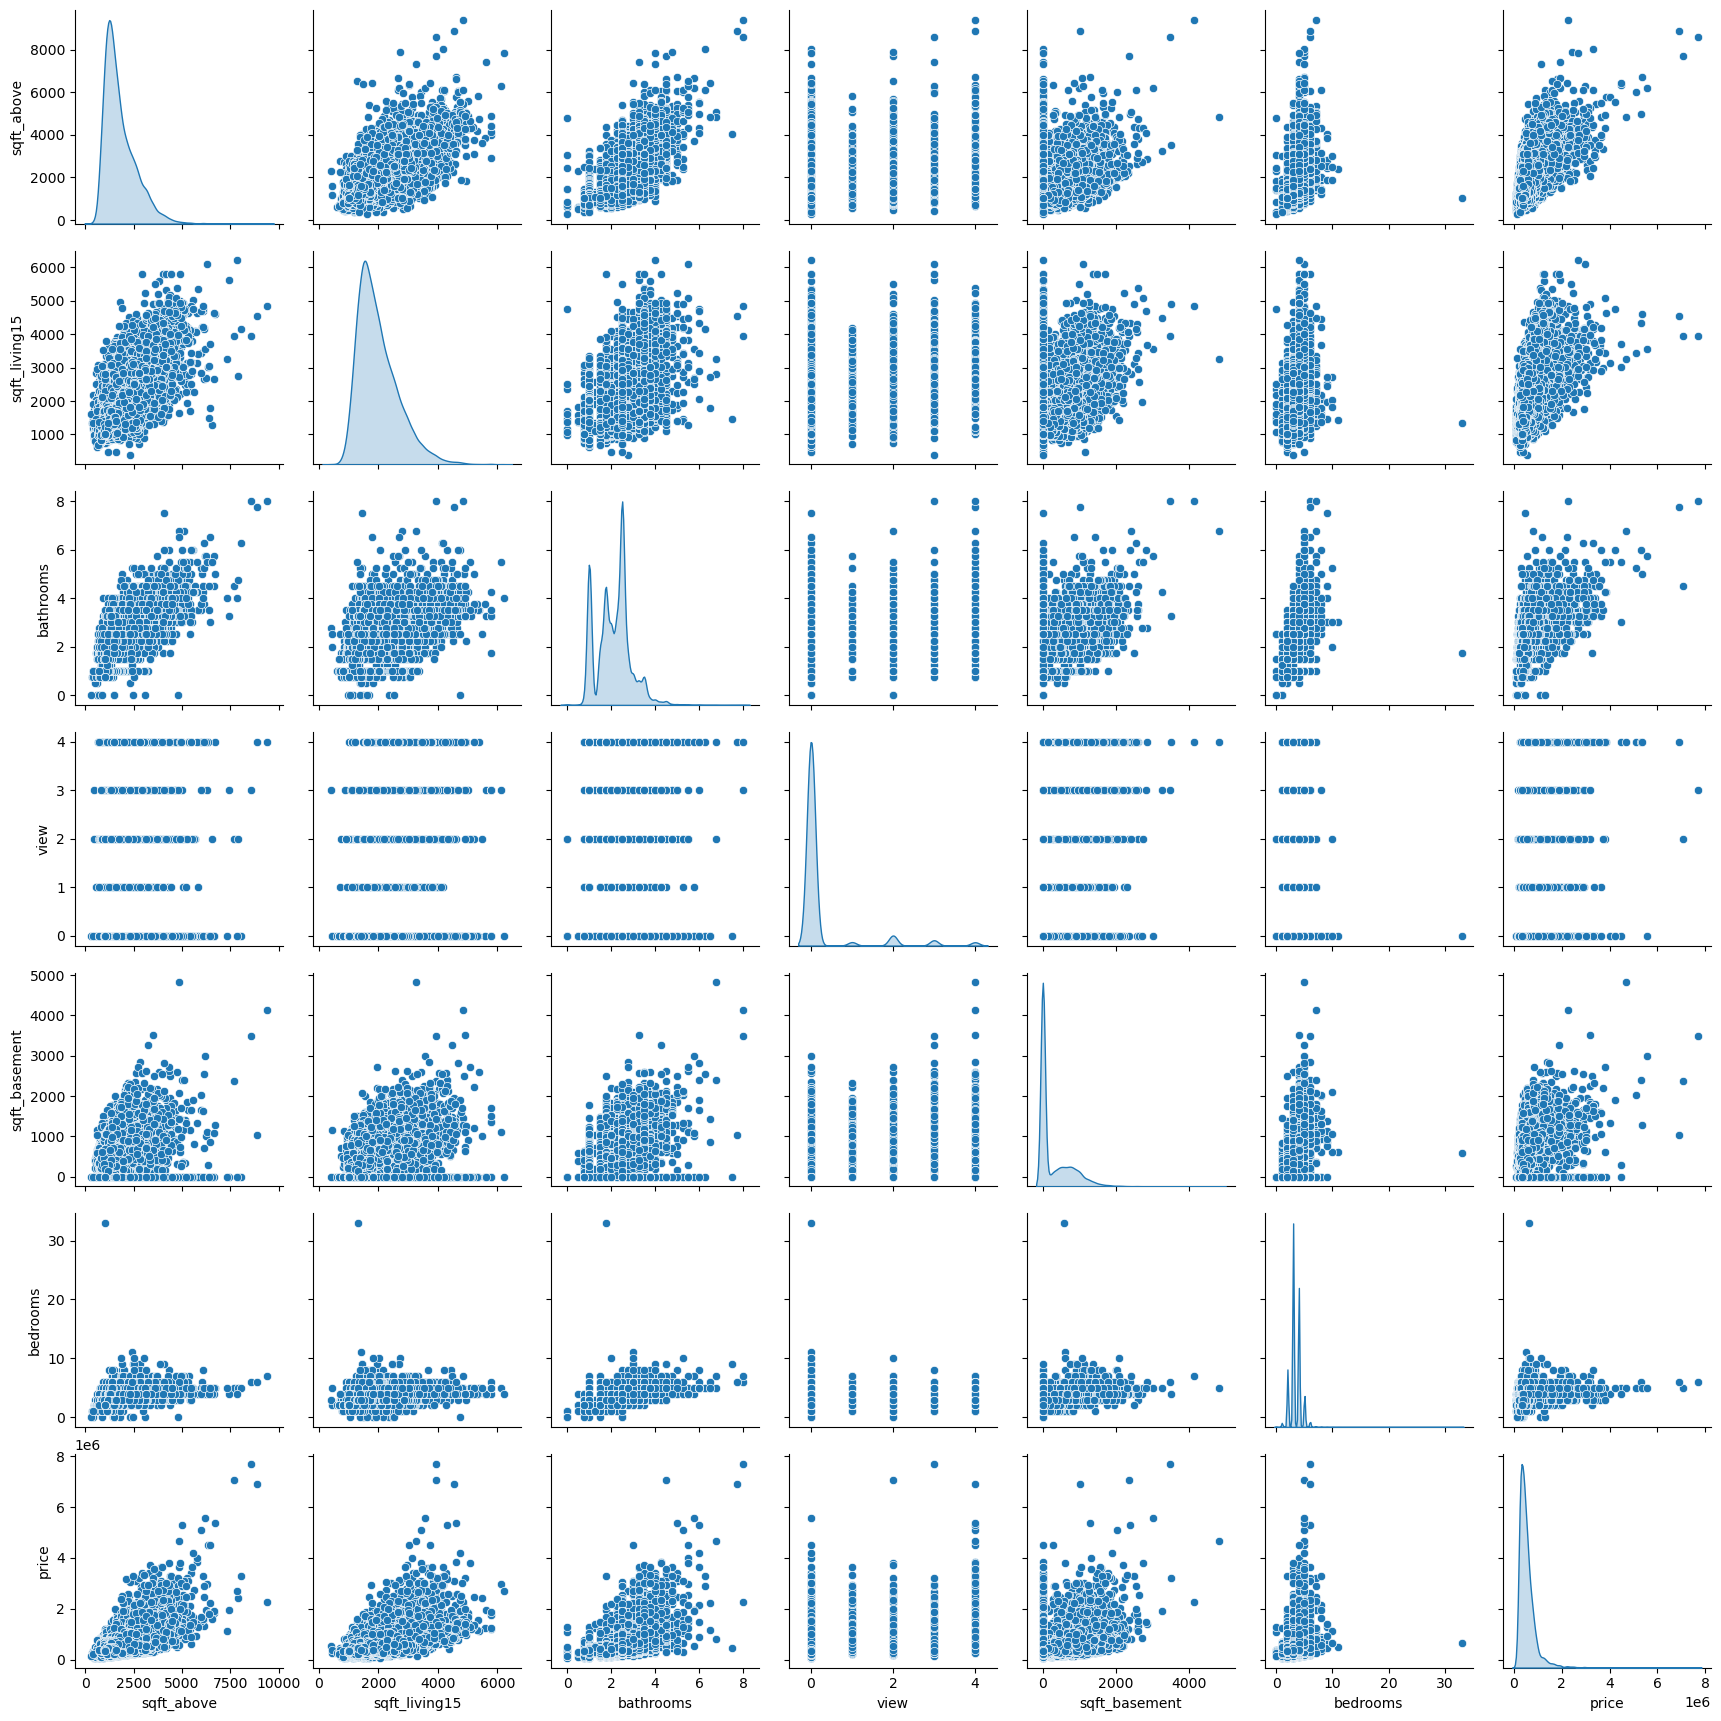

In [884]:
features = ['sqft_above', 'sqft_living15', 'bathrooms', 'view', 'sqft_basement', 'bedrooms' , 'price']
sns.pairplot(df_modified, vars=features, diag_kind='kde');

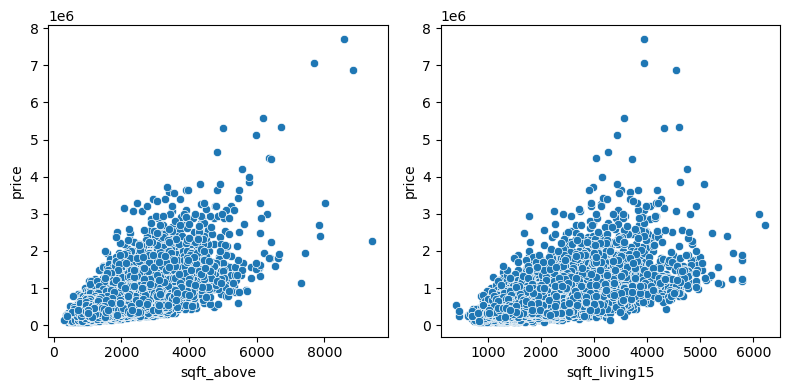

In [885]:
plt.figure(figsize=(8 , 4))
plt.subplot(1,2,1)
sns.scatterplot(x = df_modified['sqft_above'] , y  = df_modified['price']);
plt.subplot(1,2,2)
sns.scatterplot(x = df_modified['sqft_living15'] , y  = df_modified['price']);
plt.tight_layout()

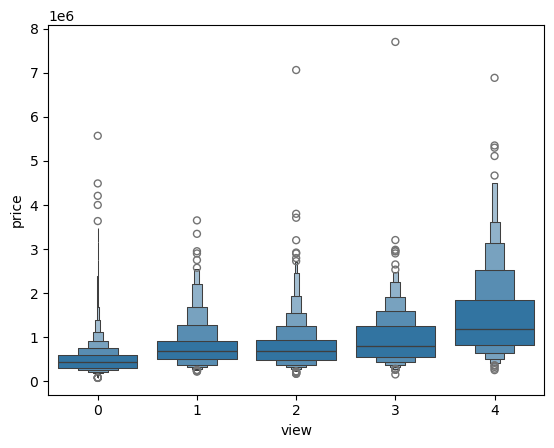

In [886]:
sns.boxenplot(x = df_modified['view'] , y  = df_modified['price']);

In [887]:
df_modified[(df_modified['bedrooms'] == 0) | (df_modified['bathrooms'] == 0)]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
875,20140612T000000,1095000.0,0,0.00,3064,4764,3.5,0,2,3,3064,0,1990,0,47.6362,-122.322,2360,4000
1149,20150217T000000,75000.0,1,0.00,670,43377,1.0,0,0,3,670,0,1966,0,47.2638,-121.906,1160,42882
3119,20150205T000000,380000.0,0,0.00,1470,979,3.0,0,2,3,1470,0,2006,0,47.7145,-122.356,1470,1399
3467,20140805T000000,288000.0,0,1.50,1430,1650,3.0,0,0,3,1430,0,1999,0,47.7222,-122.290,1430,1650
4868,20141002T000000,228000.0,0,1.00,390,5900,1.0,0,0,2,390,0,1953,0,47.5260,-122.261,2170,6000
5832,20141104T000000,280000.0,1,0.00,600,24501,1.0,0,0,2,600,0,1950,0,47.5316,-121.749,990,22549
6994,20140624T000000,1295650.0,0,0.00,4810,28008,2.0,0,0,3,4810,0,1990,0,47.6642,-122.069,4740,35061
8477,20141117T000000,339950.0,0,2.50,2290,8319,2.0,0,0,3,2290,0,1985,0,47.3473,-122.151,2500,8751
8484,20140925T000000,240000.0,0,2.50,1810,5669,2.0,0,0,3,1810,0,2003,0,47.3493,-122.053,1810,5685
9773,20150429T000000,355000.0,0,0.00,2460,8049,2.0,0,0,3,2460,0,1990,0,47.4095,-122.168,2520,8050


In [888]:
df_modified.head(15)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,1180,0,1955,0,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,770,0,1933,0,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,1050,910,1965,0,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,1680,0,1987,0,47.6168,-122.045,1800,7503
5,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,3,3890,1530,2001,0,47.6561,-122.005,4760,101930
6,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,3,1715,0,1995,0,47.3097,-122.327,2238,6819
7,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,3,1060,0,1963,0,47.4095,-122.315,1650,9711
8,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,3,1050,730,1960,0,47.5123,-122.337,1780,8113
9,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,3,1890,0,2003,0,47.3684,-122.031,2390,7570


In [889]:
df_modified.tail(15)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
21598,20141013T000000,541800.0,4,2.50,3118,7866,2.0,0,2,3,3118,0,2014,0,47.2931,-122.264,2673,6500
21599,20140915T000000,810000.0,4,3.00,3990,7838,2.0,0,0,3,3990,0,2003,0,47.6857,-122.046,3370,6814
21600,20141015T000000,1537000.0,5,3.75,4470,8088,2.0,0,0,3,4470,0,2008,0,47.6321,-122.200,2780,8964
21601,20150407T000000,467000.0,3,2.50,1425,1179,3.0,0,0,3,1425,0,2008,0,47.6963,-122.318,1285,1253
21602,20140626T000000,224000.0,3,1.75,1500,11968,1.0,0,0,3,1500,0,2014,0,47.3095,-122.002,1320,11303
21603,20140825T000000,507250.0,3,2.50,2270,5536,2.0,0,0,3,2270,0,2003,0,47.5389,-121.881,2270,5731
21604,20150126T000000,429000.0,3,2.00,1490,1126,3.0,0,0,3,1490,0,2014,0,47.5699,-122.288,1400,1230
21605,20141014T000000,610685.0,4,2.50,2520,6023,2.0,0,0,3,2520,0,2014,0,47.5137,-122.167,2520,6023
21606,20150326T000000,1007500.0,4,3.50,3510,7200,2.0,0,0,3,2600,910,2009,0,47.5537,-122.398,2050,6200
21607,20150219T000000,475000.0,3,2.50,1310,1294,2.0,0,0,3,1180,130,2008,0,47.5773,-122.409,1330,1265


In [890]:
df_modified.isna().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

##### stratified splitting

In [30]:
bins = [0 , 1000 , 2000, 3000, 4000, 5000, np.inf]
labels =[1, 2, 3, 4, 5, 6]
df_modified['binned_sqft_above'] = pd.cut(df['sqft_above'], bins=bins, labels=labels)

In [32]:
input_set = df_modified.drop(columns=['price'])
output_set = df_modified['price']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(input_set,output_set, test_size=0.2, stratify=df_modified['binned_sqft_above'], random_state=42)

In [36]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((17290, 18), (4323, 18), (17290,), (4323,))

In [38]:
X_train = X_train.drop(columns=['binned_sqft_above'])
X_test = X_test.drop(columns=['binned_sqft_above'])

In [40]:
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((17290, 17), (4323, 17), (17290,), (4323,))

### Data cleaning

#### extracting date

In [902]:
X_train.isna().sum()

date             0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

In [903]:
df_modified.sort_values(by = ['price']).head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,binned_sqft_above
1149,20150217T000000,75000.0,1,0.00,670,43377,1.0,0,0,3,670,0,1966,0,47.2638,-121.906,1160,42882,1
15293,20140506T000000,78000.0,2,1.00,780,16344,1.0,0,0,1,780,0,1942,0,47.4739,-122.280,1700,10387,1
465,20140523T000000,80000.0,1,0.75,430,5050,1.0,0,0,2,430,0,1912,0,47.6499,-121.909,1200,7500,1
16198,20150324T000000,81000.0,2,1.00,730,9975,1.0,0,0,1,730,0,1943,0,47.4808,-122.315,860,9000,1
8274,20141105T000000,82000.0,3,1.00,860,10426,1.0,0,0,3,860,0,1954,0,47.4987,-122.341,1140,11250,1
2141,20140508T000000,82500.0,2,1.00,520,22334,1.0,0,0,2,520,0,1951,0,47.4799,-122.296,1572,10570,1
18468,20140529T000000,83000.0,2,1.00,900,8580,1.0,0,0,3,900,0,1918,0,47.4727,-122.270,2060,6533,1
3767,20150430T000000,84000.0,2,1.00,700,20130,1.0,0,0,3,700,0,1949,0,47.4752,-122.271,1490,18630,1
16714,20150305T000000,85000.0,2,1.00,910,9753,1.0,0,0,3,910,0,1947,0,47.3897,-122.236,1160,7405,1
10253,20140915T000000,85000.0,2,1.00,830,9000,1.0,0,0,3,830,0,1939,0,47.3813,-122.243,1160,7680,1


In [904]:
df_modified.sort_values(by = ['price']).tail(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,binned_sqft_above
8638,20140618T000000,4489000.0,4,3.00,6430,27517,2.0,0,0,3,6430,0,2001,0,47.6208,-122.219,3720,14592,6
2626,20140815T000000,4500000.0,5,5.50,6640,40014,2.0,1,4,3,6350,290,2004,0,47.7493,-122.280,3030,23408,6
8092,20140617T000000,4668000.0,5,6.75,9640,13068,1.0,1,4,3,4820,4820,1983,2009,47.5570,-122.210,3270,10454,5
1164,20141020T000000,5110800.0,5,5.25,8010,45517,2.0,1,4,3,5990,2020,1999,0,47.6767,-122.211,3430,26788,6
1315,20150413T000000,5300000.0,6,6.00,7390,24829,2.0,1,4,4,5000,2390,1991,0,47.5631,-122.210,4320,24619,5
1448,20150413T000000,5350000.0,5,5.00,8000,23985,2.0,0,4,3,6720,1280,2009,0,47.6232,-122.220,4600,21750,6
4411,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,0,0,3,6200,3000,2001,0,47.6289,-122.233,3560,24345,6
9254,20140919T000000,6885000.0,6,7.75,9890,31374,2.0,0,4,3,8860,1030,2001,0,47.6305,-122.240,4540,42730,6
3914,20140611T000000,7062500.0,5,4.50,10040,37325,2.0,1,2,3,7680,2360,1940,2001,47.6500,-122.214,3930,25449,6
7252,20141013T000000,7700000.0,6,8.00,12050,27600,2.5,0,3,4,8570,3480,1910,1987,47.6298,-122.323,3940,8800,6


#### The outliers are logical and represents real data not errors, so I will keep them.

In [906]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.002, random_state=42)
iso_forest.fit(X_train.select_dtypes(include=np.number))

X_train['anomaly'] = iso_forest.predict(X_train.select_dtypes(include=np.number))

In [907]:
X_train[X_train['anomaly'] == -1]

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,anomaly
7252,20141013T000000,6,8.00,12050,27600,2.5,0,3,4,8570,3480,1910,1987,47.6298,-122.323,3940,8800,-1
15482,20140812T000000,4,3.25,7000,28206,1.0,1,4,4,3500,3500,1991,0,47.5928,-122.086,4913,14663,-1
14556,20140611T000000,5,6.25,8670,64033,2.0,0,4,3,6120,2550,1965,2003,47.7295,-122.372,4140,81021,-1
2626,20140815T000000,5,5.50,6640,40014,2.0,1,4,3,6350,290,2004,0,47.7493,-122.280,3030,23408,-1
1164,20141020T000000,5,5.25,8010,45517,2.0,1,4,3,5990,2020,1999,0,47.6767,-122.211,3430,26788,-1
1719,20150327T000000,4,1.00,1300,1651359,1.0,0,3,4,1300,0,1920,0,47.2313,-122.023,2560,425581,-1
3934,20140723T000000,3,3.25,3786,38038,1.0,1,4,3,1934,1852,1978,2006,47.3907,-122.448,2850,33361,-1
11729,20140623T000000,4,2.50,4570,74487,2.0,0,4,5,4570,0,1948,1985,47.7282,-122.372,3810,74487,-1
7907,20140923T000000,6,5.00,7100,18200,2.5,0,0,3,5240,1860,1933,2002,47.6427,-122.408,3130,6477,-1
8156,20140522T000000,2,1.75,2860,59612,1.0,1,4,3,1510,1350,1948,2003,47.3276,-122.389,2720,59612,-1


In [908]:
X_train = X_train.drop(columns=['anomaly'])

In [909]:
X_train.duplicated().sum()

1

### extracting date and some feature engineering

In [911]:
x_train_copy= X_train.copy()

In [912]:
o = pd.to_datetime(x_train_copy['date']).dt.year

In [913]:
o.value_counts()

date
2014    11723
2015     5567
Name: count, dtype: int64

### transformers

In [915]:
from sklearn.preprocessing import FunctionTransformer
    
log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

In [916]:
from sklearn.cluster import KMeans

long_lat_clusters_transformer = KMeans(n_clusters=10, random_state=42, n_init=4)



In [917]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DateYearExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X)
        # Result is a 1-column DataFrame
        return pd.to_datetime(X.iloc[:, 0]).dt.year.to_frame()

    def get_feature_names_out(self, input_features=None):
        # This ensures the output column is named 'year_sold'
        return ["extracted"]

year_extractor = DateYearExtractor()


In [918]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class FeatureRatioTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, eps=1e-6):
        self.eps = eps  # Small constant to prevent division by zero
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # Calculation: (f1 + f2) / f3
        numerator = X.iloc[:, 0] + X.iloc[:, 1]
        denominator = X.iloc[:, 2] + self.eps
        
        ratio = numerator / denominator
        return ratio.to_frame()

    # ADDED METHOD FOR NAMING
    def get_feature_names_out(self, input_features=None):
        return ["calculated"]
three_features_ratio = FeatureRatioTransformer()

In [919]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class SimpleRatioTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, eps=1e-6):
        self.eps = eps
        
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        # Convert to DataFrame if it's a numpy array to use iloc
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # Calculation: Feature 1 / (Feature 2 + epsilon)
        ratio = X.iloc[:, 0] / (X.iloc[:, 1] + self.eps)
        
        # Enforce 2D output for Scikit-Learn compatibility
        return ratio.to_frame()

    def get_feature_names_out(self, input_features=None):
        # This tells ColumnTransformer to name the output column 'lot_ratio'
        return ["calculated"]

two_features_ratio=SimpleRatioTransformer()

In [920]:
x_train_copy.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15',
       'sqft_lot15'],
      dtype='object')

### Preprocessing

In [922]:
from sklearn.preprocessing import StandardScaler,TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [923]:
date_pipeline = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent') ),
    ('year_extract' , DateYearExtractor()),
    ('scaler' , StandardScaler())    
])

In [924]:
date_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('year_extract', DateYearExtractor()),
                ('scaler', StandardScaler())])

In [925]:
log_num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transformer', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

In [926]:
log_num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('log_transformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [927]:
cluster_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('cluster_transformer',KMeans(n_clusters=37, random_state=42, n_init=10) ),
    ('scaler', StandardScaler())
])

In [928]:
cluster_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('cluster_transformer',
                 KMeans(n_clusters=37, n_init=10, random_state=42)),
                ('scaler', StandardScaler())])

In [929]:
sqft_living_ratio_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('Triple_feature_ratio_transformer', FeatureRatioTransformer() ),
    ('scaler', StandardScaler())
])

In [930]:
sqft_living_ratio_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('Triple_feature_ratio_transformer', FeatureRatioTransformer()),
                ('scaler', StandardScaler())])

In [931]:
sqft_lot_ratio_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('simple_ratio_transformer', SimpleRatioTransformer() ),
    ('scaler', StandardScaler())
])

In [932]:
sqft_lot_ratio_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('simple_ratio_transformer', SimpleRatioTransformer()),
                ('scaler', StandardScaler())])

In [933]:
default_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
     ('log_transformer', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

In [934]:
default_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('log_transformer',
                 FunctionTransformer(feature_names_out='one-to-one',
                                     func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [935]:
no_scaler_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent'))])

In [936]:
no_scaler_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'))])

In [937]:
from sklearn.compose import ColumnTransformer

In [939]:
num_features = ['bedrooms', 'bathrooms', 'sqft_lot', 'floors','sqft_above', 'sqft_basement','sqft_living15', 'sqft_lot15',
                'view','condition']

In [948]:
preprocessing = ColumnTransformer(transformers=[
    ('geo' , cluster_pipeline, ['long' , 'lat']),
    ('sqft_lot_ratio' , sqft_lot_ratio_pipeline , ['sqft_lot' , 'sqft_lot15']),
    ('sqft_living_ratio' , sqft_lot_ratio_pipeline , ['sqft_living', 'sqft_living15']),
    ('year_sold' , date_pipeline , ['date']),
    ('logged' , log_num_pipeline , num_features),
    ('logged_yr' , default_pipeline , ['yr_built', 'yr_renovated']),
    ('binary' , no_scaler_pipeline , ['waterfront'])])

In [987]:
preprocessing

ColumnTransformer(transformers=[('geo',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cluster_transformer',
                                                  KMeans(n_clusters=37,
                                                         n_init=10,
                                                         random_state=42)),
                                                 ('scaler', StandardScaler())]),
                                 ['long', 'lat']),
                                ('sqft_lot_ratio',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('simple_ratio_transformer',
                                                  SimpleRatioTransfo...
                                  'sqft_living15', 'sqft_lot15', 'view',
                                  'condition']),
                                ('logged_yr',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('log_transformer',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['yr_built', 'yr_renovated']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['waterfront'])])

In [989]:
x_train_copy.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'lat', 'long', 'sqft_living15',
       'sqft_lot15'],
      dtype='object')

In [991]:
ex = preprocessing.fit_transform(x_train_copy,Y_train) 

In [993]:
ex.shape

(17290, 53)

In [995]:
preprocessing.get_feature_names_out() 

array(['geo__kmeans0', 'geo__kmeans1', 'geo__kmeans2', 'geo__kmeans3',
       'geo__kmeans4', 'geo__kmeans5', 'geo__kmeans6', 'geo__kmeans7',
       'geo__kmeans8', 'geo__kmeans9', 'geo__kmeans10', 'geo__kmeans11',
       'geo__kmeans12', 'geo__kmeans13', 'geo__kmeans14', 'geo__kmeans15',
       'geo__kmeans16', 'geo__kmeans17', 'geo__kmeans18', 'geo__kmeans19',
       'geo__kmeans20', 'geo__kmeans21', 'geo__kmeans22', 'geo__kmeans23',
       'geo__kmeans24', 'geo__kmeans25', 'geo__kmeans26', 'geo__kmeans27',
       'geo__kmeans28', 'geo__kmeans29', 'geo__kmeans30', 'geo__kmeans31',
       'geo__kmeans32', 'geo__kmeans33', 'geo__kmeans34', 'geo__kmeans35',
       'geo__kmeans36', 'sqft_lot_ratio__calculated',
       'sqft_living_ratio__calculated', 'year_sold__extracted',
       'logged__bedrooms', 'logged__bathrooms', 'logged__sqft_lot',
       'logged__floors', 'logged__sqft_above', 'logged__sqft_basement',
       'logged__sqft_living15', 'logged__sqft_lot15', 'logged__view',
       

In [997]:
preprocessing.get_params()

{'force_int_remainder_cols': True,
 'n_jobs': None,
 'remainder': 'drop',
 'sparse_threshold': 0.3,
 'transformer_weights': None,
 'transformers': [('geo',
   Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                   ('cluster_transformer',
                    KMeans(n_clusters=37, n_init=10, random_state=42)),
                   ('scaler', StandardScaler())]),
   ['long', 'lat']),
  ('sqft_lot_ratio',
   Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                   ('simple_ratio_transformer', SimpleRatioTransformer()),
                   ('scaler', StandardScaler())]),
   ['sqft_lot', 'sqft_lot15']),
  ('sqft_living_ratio',
   Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                   ('simple_ratio_transformer', SimpleRatioTransformer()),
                   ('scaler', StandardScaler())]),
   ['sqft_living', 'sqft_living15']),
  ('year_sold',
   Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent'

### Model selection

In [81]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline([
    ('preprocessing', preprocessing),
    ('regressor', LinearRegression())
])

In [82]:
linear_model.fit(X_train, Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=20,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                   'sqft_above',
                                                   'sqft_basement',
                                                   'sqft_living15',
                                                   'sqft_lot15', 'view',
                                                   'condition']),
                                                 ('scaled_only',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('regressor', LinearRegression())])

In [83]:
from sklearn.metrics import root_mean_squared_error

lin_train_pred = linear_model.predict(X_train)
lin_rmse_train = root_mean_squared_error(Y_train, lin_train_pred)
lin_rmse_train


197661.58921150243

In [84]:
np.std(df['price'])

367118.7031813722

In [85]:
from sklearn.metrics import mean_absolute_percentage_error

lin_mape_train = mean_absolute_percentage_error(Y_train, lin_train_pred)
lin_mape_train

0.25340434779683596

In [86]:
from sklearn.ensemble import RandomForestRegressor

randf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(random_state=42))
])
randf_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=20,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                   'sqft_living15',
                                                   'sqft_lot15', 'view',
                                                   'condition']),
                                                 ('scaled_only',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg', RandomForestRegressor(random_state=42))])

In [87]:
randf_model.fit(X_train,Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=20,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                   'sqft_living15',
                                                   'sqft_lot15', 'view',
                                                   'condition']),
                                                 ('scaled_only',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg', RandomForestRegressor(random_state=42))])

In [88]:
randf_train_pred = randf_model.predict(X_train)

In [89]:
randf_rmse_train = root_mean_squared_error(Y_train, randf_train_pred)
randf_rmse_train

49238.57404797705

In [90]:
randf_mape_train = mean_absolute_percentage_error(Y_train, randf_train_pred)
randf_mape_train

0.049757172329031464

#### checking cv_score

In [97]:
randf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(random_state=42))
])
randf_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=20,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                   'sqft_living15',
                                                   'sqft_lot15', 'view',
                                                   'condition']),
                                                 ('scaled_only',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg', RandomForestRegressor(random_state=42))])

### This cell will take few minutes

In [98]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results = cross_validate(
    randf_model, 
    X_train, Y_train, 
    cv=10, 
    n_jobs=14,
    verbose=3,
    scoring=scoring,
    return_train_score=True
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   3 out of  10 | elapsed:  1.3min remaining:  3.1min
[Parallel(n_jobs=14)]: Done   7 out of  10 | elapsed:  1.4min remaining:   34.8s
[Parallel(n_jobs=14)]: Done  10 out of  10 | elapsed:  1.4min finished


In [99]:
-cv_results['train_rmse'].mean(), -cv_results['test_rmse'].mean(),

(49145.18456899611, 131535.1670516121)

In [100]:
-cv_results['train_mape'].mean(), -cv_results['test_mape'].mean(),

(0.049947320563884394, 0.13404312075478314)

### Tuning hyperparameters (random forest)

In [102]:
randf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(random_state=42))
])
randf_model

"randf_model = Pipeline([\n    ('preprocessing', preprocessing),\n    ('random_forest_reg', RandomForestRegressor(random_state=42))\n])\nrandf_model"

In [4]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'preprocessing__geo__cluster_transformer__n_clusters': randint(3, 50),
    'random_forest_reg__n_estimators': randint(100, 800),
    'random_forest_reg__max_depth': randint(3, 40),
    'random_forest_reg__min_samples_split': randint(2, 30),
    'random_forest_reg__min_samples_leaf': randint(1, 30),
    'random_forest_reg__max_features': randint(3, 30),
}

random_search = RandomizedSearchCV(
    estimator=randf_model,
    param_distributions=param_distributions,
    n_iter=25,
    cv=7,
    scoring='neg_mean_absolute_percentage_error',
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

"from sklearn.model_selection import RandomizedSearchCV\nfrom scipy.stats import randint\n\nparam_distributions = {\n    'preprocessing__geo__cluster_transformer__n_clusters': randint(3, 50),\n    'random_forest_reg__n_estimators': randint(100, 800),\n    'random_forest_reg__max_depth': randint(3, 40),\n    'random_forest_reg__min_samples_split': randint(2, 30),\n    'random_forest_reg__min_samples_leaf': randint(1, 30),\n    'random_forest_reg__max_features': randint(3, 30),\n}\n\nrandom_search = RandomizedSearchCV(\n    estimator=randf_model,\n    param_distributions=param_distributions,\n    n_iter=25,\n    cv=7,\n    scoring='neg_mean_absolute_percentage_error',\n    verbose=2,\n    random_state=42,\n    n_jobs=-1,\n    return_train_score=True\n)"

### This cell will take few minutes

In [104]:
random_search.fit(X_train, Y_train)

'random_search.fit(X_train, Y_train)'

In [105]:
random_search_results_df = pd.DataFrame( random_search.cv_results_)
random_search_results_df = random_search_results_df.sort_values(by=['rank_test_score'])
random_search_results_df

"random_search_results_df = pd.DataFrame( random_search.cv_results_)\nrandom_search_results_df = random_search_results_df.sort_values(by=['rank_test_score'])\nrandom_search_results_df"

In [106]:
display_cols = ['params', 'mean_test_score', 'mean_train_score', 'std_test_score','std_train_score', 'mean_fit_time']
random_search_results_df[display_cols].head(5)

"display_cols = ['params', 'mean_test_score', 'mean_train_score', 'std_test_score','std_train_score', 'mean_fit_time']\nrandom_search_results_df[display_cols].head(5)"

In [107]:
final_model = random_search.best_estimator_

'final_model = random_search.best_estimator_'

In [108]:
feature_importance = final_model['random_forest_reg'].feature_importances_
sorted(zip(feature_importance , final_model['preprocessing'].get_feature_names_out() ), reverse=True

"feature_importance = final_model['random_forest_reg'].feature_importances_\nsorted(zip(feature_importance , final_model['preprocessing'].get_feature_names_out() ), reverse=True)"

In [109]:
import joblib
joblib.dump(final_model , 'kings_county_housing_model.pkl')

"import joblib\njoblib.dump(final_model , 'kings_county_housing_model.pkl')"

In [110]:
import joblib
final_model_v1 = joblib.load('kings_county_housing_model.pkl')

In [111]:
final_model_v1_pred = final_model_v1.predict(X_train)
mean_absolute_percentage_error(Y_train,final_model_v1_pred)

0.07843906059149237

In [112]:
final_model_v1_pred = final_model_v1.predict(X_test)
mean_absolute_percentage_error(Y_test,final_model_v1_pred)

0.13073298979583034

In [113]:
root_mean_squared_error(Y_test,final_model_v1_pred)

131897.7363322305

In [114]:
final_model_v1['random_forest_reg']

RandomForestRegressor(max_depth=28, max_features=14, min_samples_leaf=2,
                      min_samples_split=11, n_estimators=369, random_state=42)

In [115]:
final_model_v1['preprocessing']

ColumnTransformer(transformers=[('geo',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cluster_transformer',
                                                  KMeans(n_clusters=20,
                                                         n_init=10,
                                                         random_state=42)),
                                                 ('scaler', StandardScaler())]),
                                 ['long', 'lat']),
                                ('sqft_lot_ratio',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('simple_ratio_transformer',
                                                  SimpleRatioTransfo...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['view', 'condition']),
                                ('scaled_only',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('scaler', StandardScaler())]),
                                 ['yr_built', 'yr_renovated']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['waterfront'])])

In [116]:
sorted(zip(final_model_v1['random_forest_reg'].feature_importances_ , final_model_v1['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.19049915848298424, 'logged__sqft_living15'),
 (0.17787872426950394, 'logged__sqft_above'),
 (0.09168035535263308, 'logged__bathrooms'),
 (0.05083326452793582, 'geo__kmeans18'),
 (0.05017618954109952, 'geo__kmeans16'),
 (0.03595521707743539, 'geo__kmeans2'),
 (0.0356280133881715, 'sqft_living_ratio__calculated'),
 (0.029627651185461356, 'geo__kmeans12'),
 (0.02528434608012993, 'geo__kmeans13'),
 (0.02422290094630499, 'binary__waterfront'),
 (0.024064542588107838, 'geo__kmeans4'),
 (0.023623584916948676, 'geo__kmeans6'),
 (0.023143050018283717, 'encoded__view_0'),
 (0.02007768385824069, 'logged__sqft_basement'),
 (0.018066480018961217, 'geo__kmeans1'),
 (0.01775744333559634, 'geo__kmeans7'),
 (0.017311265354851516, 'encoded__view_4'),
 (0.017011220569858702, 'geo__kmeans19'),
 (0.016053484712584325, 'geo__kmeans9'),
 (0.012435322528108085, 'logged__sqft_lot'),
 (0.010272319275720143, 'geo__kmeans11'),
 (0.00989659684661051, 'logged__sqft_lot15'),
 (0.00925556801249537, 'geo__kmeans14

### Fixing the data and pipelines and more tuning to make the performance better

### V2 of the model

### This cell will take few minutes

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'preprocessing__geo__cluster_transformer__n_clusters': [18,20,22,25,27],
    
}


grid_search_v2 = GridSearchCV(
    randf_model_v2, 
    param_grid, 
    cv=3,                  
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=14,             
    verbose=3,
    return_train_score=True
)

grid_search_v2.fit(X_train,Y_train)

In [207]:
randf_model_v2 = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(max_depth=28, max_features=14, min_samples_leaf=2,
                      min_samples_split=11, n_estimators=369, random_state=42))
])

In [209]:
randf_model_v2.fit(X_train,Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=25,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg',
                 RandomForestRegressor(max_depth=28, max_features=14,
                                       min_samples_leaf=2, min_samples_split=11,
                                       n_estimators=369, random_state=42))])

### This cell will take few minutes

In [ ]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results_v2 = cross_validate(
    randf_model_v2, 
    X_train, Y_train, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=14,
    verbose = 3

In [121]:
-cv_results_v2['train_rmse'].mean(), -cv_results_v2['test_rmse'].mean()

(80936.2842202096, 131352.16969784262)

In [122]:
-cv_results_v2['train_mape'].mean(), -cv_results_v2['test_mape'].mean(),

(0.07777153245942044, 0.13188062279045895)

In [193]:
sorted(zip(randf_model_v2['random_forest_reg'].feature_importances_ , randf_model_v2['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.1981660706329972, 'logged__sqft_living15'),
 (0.17997359294581508, 'logged__sqft_above'),
 (0.09135390896013605, 'logged__bathrooms'),
 (0.0506846245722368, 'geo__kmeans23'),
 (0.042327294750890705, 'geo__kmeans21'),
 (0.04145819479436786, 'geo__kmeans9'),
 (0.035946181533950995, 'logged__view'),
 (0.035106641214569904, 'sqft_living_ratio__calculated'),
 (0.034197947451366124, 'geo__kmeans5'),
 (0.026336972789489807, 'geo__kmeans8'),
 (0.024462070969199057, 'binary__waterfront'),
 (0.01971343064406519, 'logged__sqft_basement'),
 (0.01930518939126619, 'geo__kmeans3'),
 (0.018593853218082542, 'geo__kmeans2'),
 (0.01764634548206952, 'geo__kmeans0'),
 (0.01648263677298033, 'geo__kmeans12'),
 (0.014761167080002599, 'geo__kmeans17'),
 (0.012282704478731648, 'logged__sqft_lot'),
 (0.012158767365423706, 'geo__kmeans18'),
 (0.011203464013430002, 'geo__kmeans20'),
 (0.010377901151280813, 'geo__kmeans14'),
 (0.009453753160598054, 'logged__sqft_lot15'),
 (0.007915919503290937, 'geo__kmeans16')

#### after more tuning

### This cell will take few minutes

In [211]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'random_forest_reg__n_estimators': [370,420],
    'random_forest_reg__max_depth': [26,28,30],
    'random_forest_reg__min_samples_split': [10,13],
    'random_forest_reg__min_samples_leaf':[2,4],
    'random_forest_reg__max_features': [12,15],
}


grid_search_v2 = GridSearchCV(
    randf_model_v2, 
    param_grid, 
    cv=3,                  
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=14,             
    verbose=3,
    return_train_score=True
)

grid_search_v2.fit(X_train,Y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessing',
                                        ColumnTransformer(transformers=[('geo',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('cluster_transformer',
                                                                                          KMeans(n_clusters=25,
                                                                                                 n_init=10,
                                                                                                 random_state=42)),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['long',
                                                                          'lat']),
                                                                        ('sqft_lot_ratio',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strat...
                                                              n_estimators=369,
                                                              random_state=42))]),
             n_jobs=14,
             param_grid={'random_forest_reg__max_depth': [26, 28, 30],
                         'random_forest_reg__max_features': [12, 15],
                         'random_forest_reg__min_samples_leaf': [2, 4],
                         'random_forest_reg__min_samples_split': [10, 13],
                         'random_forest_reg__n_estimators': [370, 420]},
             return_train_score=True,
             scoring='neg_mean_absolute_percentage_error', verbose=3)

### This cell will take few minutes

In [233]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results_v2 = cross_validate(
    final_model_v2, 
    X_train, Y_train, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=14,
    verbose = 3
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   2 out of   5 | elapsed:  1.6min remaining:  2.4min
[Parallel(n_jobs=14)]: Done   5 out of   5 | elapsed:  1.6min finished


In [236]:
-cv_results_v2['train_rmse'].mean(), -cv_results_v2['test_rmse'].mean()

(79521.15528714207, 134041.4378550758)

In [238]:
-cv_results_v2['train_mape'].mean(), -cv_results_v2['test_mape'].mean(),

(0.07592913575731279, 0.13262023092219738)

In [215]:
p = grid_search_v2.best_estimator_.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.12149334143208075, 130771.21837471123)

In [223]:
joblib.dump(grid_search_v2.best_estimator_ , 'king_county_housing_model_v2.pkl')

['king_county_housing_model_v2.pkl']

In [225]:
final_model_v2 = joblib.load('king_county_housing_model_v2.pkl')

In [227]:
final_model_v2

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=25,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg',
                 RandomForestRegressor(max_depth=30, max_features=15,
                                       min_samples_leaf=2, min_samples_split=10,
                                       n_estimators=420, random_state=42))])

In [229]:
p = final_model_v2.predict(X_train)
mean_absolute_percentage_error(p,Y_train),root_mean_squared_error(p,Y_train)

(0.06967427479155634, 77745.43856193051)

In [231]:
p = final_model_v2.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.12149334143208075, 130771.21837471123)

### V3 of the model

In [469]:
randf_model_v3 = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(random_state=42))
])
randf_model_v3

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=25,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('log_transformer',
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg', RandomForestRegressor(random_state=42))])

In [481]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'preprocessing__geo__cluster_transformer__n_clusters': randint(20, 40),
    'random_forest_reg__n_estimators': randint(200, 700),
    'random_forest_reg__max_depth': randint(5,18),
    'random_forest_reg__min_samples_split': randint(10, 50),
    'random_forest_reg__min_samples_leaf': randint(10, 40),
    'random_forest_reg__max_features': randint(5, 10),
}

random_search_v3 = RandomizedSearchCV(
    estimator=randf_model_v3,
    param_distributions=param_distributions,
    n_iter=30,
    cv=6,
    scoring='neg_mean_absolute_percentage_error',
    verbose=3,
    random_state=42,
    n_jobs=6,
    return_train_score=True
)

### This cell will take few minutes

In [483]:
random_search_v3.fit(X_train,Y_train)

Fitting 6 folds for each of 30 candidates, totalling 180 fits


RandomizedSearchCV(cv=6,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('geo',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('cluster_transformer',
                                                                                                KMeans(n_clusters=25,
                                                                                                       n_init=10,
                                                                                                       random_state=42)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['long',
                                                                                'lat']),
                                                                              ('sqft_lot_ratio',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer...
                                        'random_forest_reg__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002977F8B0110>,
                                        'random_forest_reg__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002977F8B3AD0>,
                                        'random_forest_reg__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002977F80AE40>},
                   random_state=42, return_train_score=True,
                   scoring='neg_mean_absolute_percentage_error', verbose=3)

In [485]:
final_model_v3 = random_search_v3.best_estimator_

In [487]:
p = final_model_v3.predict(X_train)
mean_absolute_percentage_error(p,Y_train),root_mean_squared_error(p,Y_train)

(0.10756874590371762, 125795.93244473622)

In [489]:
p = final_model_v3.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.12784567299860347, 148929.3257179705)

In [497]:
sorted(zip(final_model_v3['random_forest_reg'].feature_importances_ , final_model_v3['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.15199851432153447, 'logged__sqft_above'),
 (0.15018810074269387, 'logged__sqft_living15'),
 (0.09123770519633016, 'logged__bathrooms'),
 (0.043600736686920036, 'logged__view'),
 (0.04333721361334434, 'geo__kmeans30'),
 (0.03377564700376653, 'geo__kmeans17'),
 (0.0302209109871467, 'geo__kmeans8'),
 (0.028615399925058776, 'geo__kmeans4'),
 (0.025307897348532487, 'geo__kmeans21'),
 (0.025162696791412507, 'sqft_living_ratio__calculated'),
 (0.01998507506092945, 'logged__sqft_basement'),
 (0.019836847849481053, 'geo__kmeans15'),
 (0.01748164439217132, 'geo__kmeans13'),
 (0.01646266145947863, 'geo__kmeans25'),
 (0.016449289081165556, 'binary__waterfront'),
 (0.015971994831833012, 'geo__kmeans10'),
 (0.01522051768211661, 'geo__kmeans16'),
 (0.013834200673527934, 'geo__kmeans23'),
 (0.01341125967623728, 'logged__sqft_lot'),
 (0.012742353773144737, 'geo__kmeans5'),
 (0.012573418982458891, 'geo__kmeans19'),
 (0.012247111488754755, 'logged__sqft_lot15'),
 (0.011966302108433522, 'geo__kmeans11

In [491]:
joblib.dump(final_model_v3 , 'king_county_housing_model_v3.pkl')

['king_county_housing_model_v3.pkl']

In [1000]:
final_model_v3 = joblib.load('king_county_housing_model_v3.pkl')

In [1002]:
p = final_model_v3.predict(X_train)
mean_absolute_percentage_error(p,Y_train),root_mean_squared_error(p,Y_train)

(0.10756874590371762, 125795.93244473622)

In [1004]:
p = final_model_v3.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.12784567299860347, 148929.3257179705)

### V 4 of the model: using target encoder on the zipcode instead of clusters

In [840]:
randf_model_v4 = Pipeline([
    ('preprocessing', preprocessing),
    ('random_forest_reg', RandomForestRegressor(max_depth=14, max_features=8, min_samples_leaf=11,
                      min_samples_split=19, n_estimators=645, random_state=42))
])
randf_model_v4

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_ratio_transformer',
                                                                   SimpleRatioTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sqft_lot', 'sqft_lot15']),
                                                 ('sqft_living_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg',
                 RandomForestRegressor(max_depth=14, max_features=8,
                                       min_samples_leaf=11,
                                       min_samples_split=19, n_estimators=645,
                                       random_state=42))])

In [842]:
randf_model_v4.fit(X_train , Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_ratio_transformer',
                                                                   SimpleRatioTransformer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sqft_lot', 'sqft_lot15']),
                                                 ('sqft_living_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                                                                   FunctionTransformer(feature_names_out='one-to-one',
                                                                                       func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['yr_built', 'yr_renovated']),
                                                 ('binary',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['waterfront'])])),
                ('random_forest_reg',
                 RandomForestRegressor(max_depth=14, max_features=8,
                                       min_samples_leaf=11,
                                       min_samples_split=19, n_estimators=645,
                                       random_state=42))])

### This cell will take few minutes

In [844]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results_v4 = cross_validate(
    randf_model_v4, 
    X_train, Y_train, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=14,
    verbose = 3
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   2 out of   5 | elapsed:   33.6s remaining:   50.4s
[Parallel(n_jobs=14)]: Done   5 out of   5 | elapsed:   34.3s finished


In [846]:
-cv_results_v4['train_rmse'].mean(), -cv_results_v4['test_rmse'].mean()

(136782.53566937632, 159000.8692932942)

In [848]:
-cv_results_v4['train_mape'].mean(), -cv_results_v4['test_mape'].mean(),

(0.13611854020319364, 0.15954368359234716)

In [850]:
p = randf_model_v4.predict(X_train)
mean_absolute_percentage_error(p,Y_train),root_mean_squared_error(p,Y_train)

(0.12489134825118953, 134542.15425802552)

In [852]:
p = randf_model_v4.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.1437416525026083, 158675.31115185222)

In [854]:
sorted(zip(randf_model_v4['random_forest_reg'].feature_importances_ , randf_model_v4['preprocessing'].get_feature_names_out() ), reverse=True)

[(0.2948079986130336, 'encoded_zipcode__zipcode'),
 (0.22744963966398626, 'logged__sqft_living15'),
 (0.18112866559519872, 'logged__sqft_above'),
 (0.08419497568728611, 'logged__bathrooms'),
 (0.05368874170206693, 'logged__view'),
 (0.05321402355312564, 'sqft_living_ratio__calculated'),
 (0.029422831017382342, 'logged__sqft_basement'),
 (0.025532083475162812, 'binary__waterfront'),
 (0.019340458730318682, 'logged_yr__yr_built'),
 (0.010677110332952535, 'logged__sqft_lot15'),
 (0.009586432458380067, 'logged__sqft_lot'),
 (0.003426512304352819, 'sqft_lot_ratio__calculated'),
 (0.002751679682485351, 'logged__bedrooms'),
 (0.0017454128167385227, 'logged__floors'),
 (0.0017159352857299055, 'logged__condition'),
 (0.0007833719425042944, 'year_sold__extracted'),
 (0.0005341271392953636, 'logged_yr__yr_renovated')]

##  XGBoost

In [1167]:
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ('preprocessing' , preprocessing),
    ('xgb_reg' , XGBRegressor(random_state = 42))
])
xgb_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=37,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [1035]:
xgb_model.fit(X_train , Y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('geo',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('cluster_transformer',
                                                                   KMeans(n_clusters=37,
                                                                          n_init=10,
                                                                          random_state=42)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['long', 'lat']),
                                                 ('sqft_lot_ratio',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('simple_rati...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [1139]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results_xgb = cross_validate(
    xgb_model_logged, 
    X_train, Y_train, 
    cv=5, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=14,
    verbose = 3
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   2 out of   5 | elapsed:    3.8s remaining:    5.7s
[Parallel(n_jobs=14)]: Done   5 out of   5 | elapsed:    3.9s finished


In [1039]:
-cv_results_xgb['train_rmse'].mean(), -cv_results_xgb['test_rmse'].mean()

(50048.76009401323, 129489.50594289685)

In [1141]:
-cv_results_xgb['train_mape'].mean(), -cv_results_xgb['test_mape'].mean(),

(0.0738783777131439, 0.1281525832246039)

In [1043]:
best_random_forest_model['random_forest_reg']

RandomForestRegressor(max_depth=14, max_features=8, min_samples_leaf=11,
                      min_samples_split=19, n_estimators=645, random_state=42)

### This cell will take few minutes

In [1171]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'xgb_reg__n_estimators': randint(500,1200),
    'xgb_reg__learning_rate': [0.01, 0.05, 0.09,0.1],
    'xgb_reg__max_depth':  randint(3,13),
    'xgb_reg__subsample': [0.7, 0.8, 0.9],
    'xgb_reg__colsample_bytree': [0.7, 0.8, 0.9],
    'xgb_reg__gamma':[0,1000, 10000, 100000, 50000],
    'xgb_reg__min_child_weight': randint(12,30),
    'xgb_reg__reg_lambda': randint(10,1000)
}

xgb_search = RandomizedSearchCV(
    xgb_model, 
    param_distributions=param_dist,
    n_iter=30, 
    cv=3, 
    scoring='neg_mean_absolute_percentage_error',
    n_jobs=14, 
    verbose=3
)

xgb_search.fit(X_train, Y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessing',
                                              ColumnTransformer(transformers=[('geo',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('cluster_transformer',
                                                                                                KMeans(n_clusters=37,
                                                                                                       n_init=10,
                                                                                                       random_state=42)),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['long',
                                                                                'lat']),
                                                                              ('sqft_lot_ratio',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer...
                                        'xgb_reg__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000297261AE570>,
                                        'xgb_reg__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000297261AC1D0>,
                                        'xgb_reg__reg_lambda': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000297261AE8A0>,
                                        'xgb_reg__subsample': [0.7, 0.8, 0.9]},
                   scoring='neg_mean_absolute_percentage_error', verbose=3)

In [1173]:
final_model_xgb = xgb_search.best_estimator_

In [1175]:
from sklearn.model_selection import cross_validate
import numpy as np

scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error'
}

cv_results_xgb = cross_validate(
    final_model_xgb, 
    X_train, Y_train, 
    cv=3, 
    scoring=scoring,
    return_train_score=True,
    n_jobs=14,
    verbose = 3
)

[Parallel(n_jobs=14)]: Using backend LokyBackend with 14 concurrent workers.
[Parallel(n_jobs=14)]: Done   3 out of   3 | elapsed:   20.3s finished


In [1179]:
-cv_results_xgb['train_rmse'].mean(), -cv_results_xgb['test_rmse'].mean()

(87778.44320920353, 127672.52558401908)

In [1177]:
-cv_results_xgb['train_mape'].mean(), -cv_results_xgb['test_mape'].mean(),

(0.08050596438818192, 0.12363643904827015)

In [1181]:
p = final_model_xgb.predict(X_test)
mean_absolute_percentage_error(p,Y_test),root_mean_squared_error(p,Y_test)

(0.11400998072294286, 127847.74878086642)

In [1185]:
import joblib
joblib.dump(final_model_xgb , 'king_county_housing_model_xgb.pkl')

['king_county_housing_model_xgb.pkl']

# the geo clusters performed better than the zipcodes and better than XGB, so the best random forest model is V3

In [1015]:
best_random_forest_model = final_model_v3

In [1017]:
import joblib
joblib.dump(best_random_forest_model , 'king_county_housing_model_best_RF.pkl')

['king_county_housing_model_best_RF.pkl']

## compute a 95% confidence interval for the test RMSE and MAPE:

In [79]:
from custom_transformers import DateYearExtractor, SimpleRatioTransformer
import joblib
import pandas as pd
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error


In [81]:
model = joblib.load('king_county_housing_model_best_RF.pkl')

In [83]:
final_predictions = model.predict(X_test)

In [85]:
from scipy import stats

def rmse(squared_errors):
    return np.sqrt(np.mean(squared_errors))

squared_errors = (final_predictions - Y_test)**2
boot_result = stats.bootstrap([squared_errors] , rmse , confidence_level=0.95 , random_state=42)
rmse_lower , rmse_upper = boot_result.confidence_interval

rmse_lower , rmse_upper

(128460.33458992168, 199182.3800176707)

In [86]:
absolute_percentage_errors = np.abs((Y_test - final_predictions) / Y_test)

def mape_estimator(data):
    return np.mean(data)

boot_result = stats.bootstrap(
    (absolute_percentage_errors,), 
    mape_estimator, 
    confidence_level=0.95, 
    random_state=42,
)

mape_lower, mape_upper = boot_result.confidence_interval

mape_lower, mape_upper

(0.13416391779701706, 0.14339304396200653)